<a href="https://colab.research.google.com/github/soup511/final_year_project/blob/main/Heart_DiseasePrediction_usingMachineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Disease Prediction using Machine Learning

## Objective

The objective of this project is to develop supervised machine learning
classification models that can predict whether a patient is likely to
have heart disease based on clinical and physiological measurements.

The project demonstrates a complete machine learning workflow:

- Data loading
- Data cleaning
- Exploratory Data Analysis (EDA)
- Data visualization
- Feature analysis
- Data preprocessing
- Train-test splitting
- Multiple classification algorithms
- Model evaluation
- Model comparison
- Feature importance analysis
- ROC-AUC analysis
- Prediction on new patient data

## Machine Learning Models

The following supervised classification algorithms will be compared:

1. Logistic Regression
2. K-Nearest Neighbours
3. Decision Tree
4. Random Forest
5. Support Vector Machine
6. Gradient Boosting

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

| Column           | Meaning                                                    | Type        | Values / Unit             |
| ---------------- | ---------------------------------------------------------- | ----------- | ------------------------- |
| `Age`            | Age of the patient                                         | Numerical   | Years                     |
| `Sex`            | Biological sex recorded for the patient                    | Categorical | `M`, `F`                  |
| `ChestPainType`  | Type of chest pain experienced                             | Categorical | `TA`, `ATA`, `NAP`, `ASY` |
| `RestingBP`      | Resting blood pressure                                     | Numerical   | mmHg                      |
| `Cholesterol`    | Serum cholesterol level                                    | Numerical   | mg/dL                     |
| `FastingBS`      | Fasting blood sugar status                                 | Binary      | `0`, `1`                  |
| `RestingECG`     | Result of resting electrocardiogram                        | Categorical | `Normal`, `ST`, `LVH`     |
| `MaxHR`          | Maximum heart rate achieved                                | Numerical   | beats/minute              |
| `ExerciseAngina` | Whether exercise induced angina                            | Categorical | `Y`, `N`                  |
| `Oldpeak`        | ST-segment depression induced by exercise relative to rest | Numerical   | Typically measured in mm  |
| `ST_Slope`       | Slope of the peak exercise ST segment                      | Categorical | `Up`, `Flat`, `Down`      |
| `HeartDisease`   | Target variable indicating heart disease status            | Binary      | `0`, `1`                  |


In [80]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [81]:
# Load the dataset

df = pd.read_csv("heart.csv")

# Display the first five rows
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


**Initial Dataset Inspection**

In [82]:
df.shape

(918, 12)

In [83]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [84]:
df.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


**Missing Values**

In [86]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


**Duplicate Values**

In [87]:
print(df.shape)
df = df.drop_duplicates()
df.shape

(918, 12)


(918, 12)

**Descriptive Statistics**

In [88]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


# Exploratory Data Analysis

Exploratory Data Analysis helps identify relationships between clinical
features and the heart disease target.

We will analyze:

- Age
- Sex
- Chest pain type
- Resting blood pressure
- Cholesterol
- Maximum heart rate
- ST depression
- Other available clinical variables

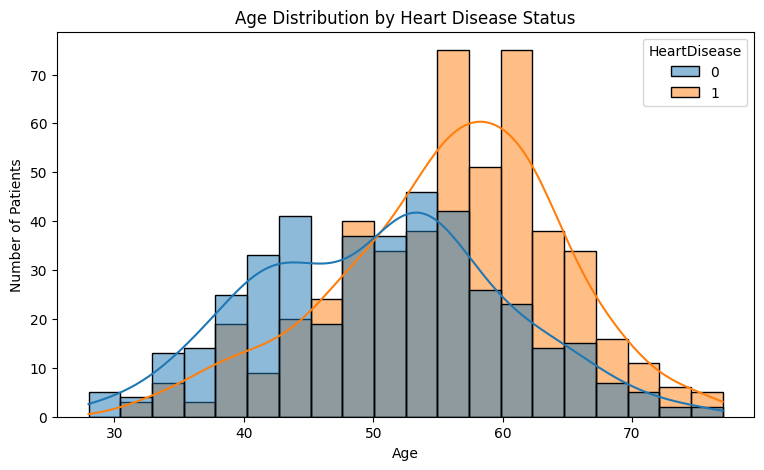

In [89]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Age",
    hue="HeartDisease",
    kde=True,
    bins=20
)

plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

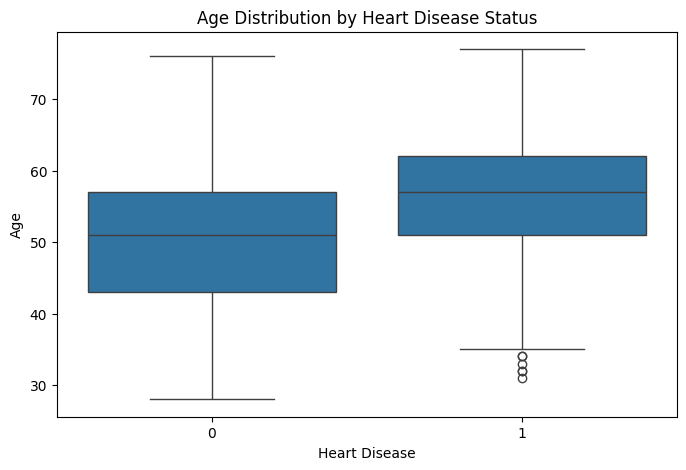

In [90]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="HeartDisease",
    y="Age"
)

plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Heart Disease")
plt.ylabel("Age")

plt.show()

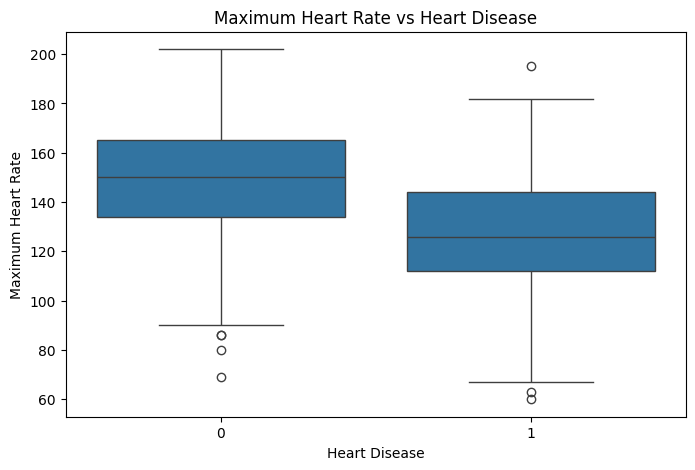

In [91]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="HeartDisease",
    y="MaxHR"
)

plt.title("Maximum Heart Rate vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Maximum Heart Rate")

plt.show()

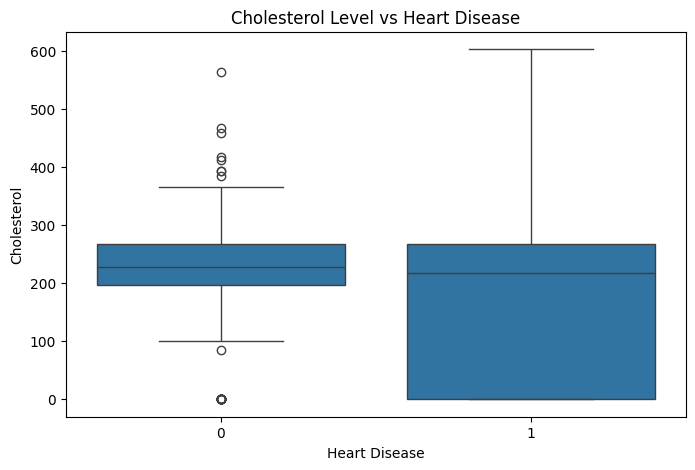

In [92]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="HeartDisease",
    y="Cholesterol"
)

plt.title("Cholesterol Level vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Cholesterol")

plt.show()

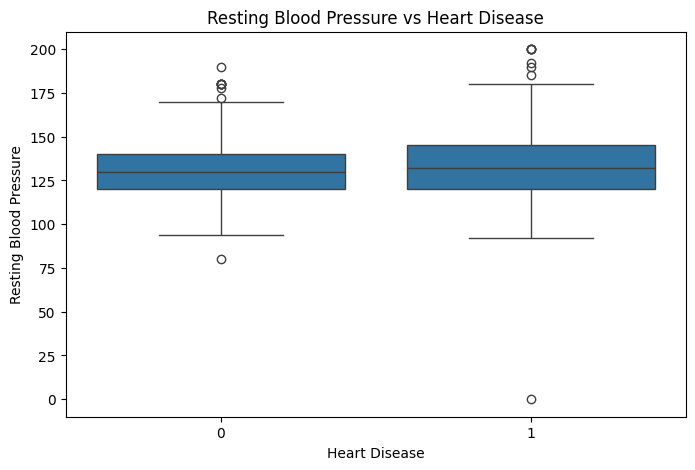

In [93]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="HeartDisease",
    y="RestingBP"
)

plt.title("Resting Blood Pressure vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Resting Blood Pressure")

plt.show()

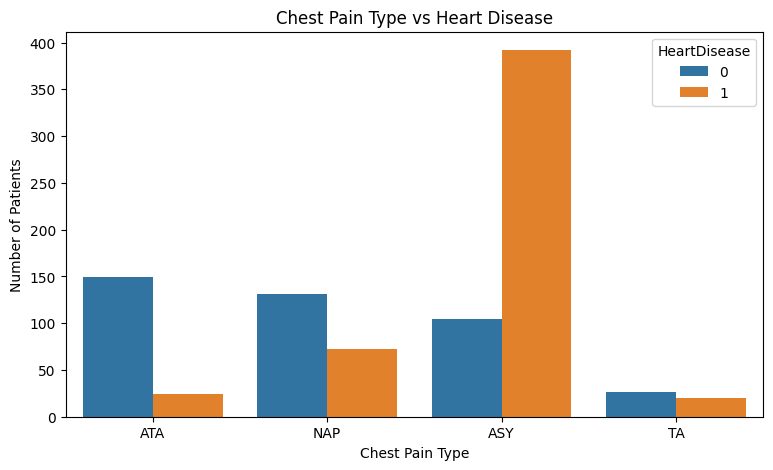

In [94]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="ChestPainType",
    hue="HeartDisease"
)

plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")

plt.show()

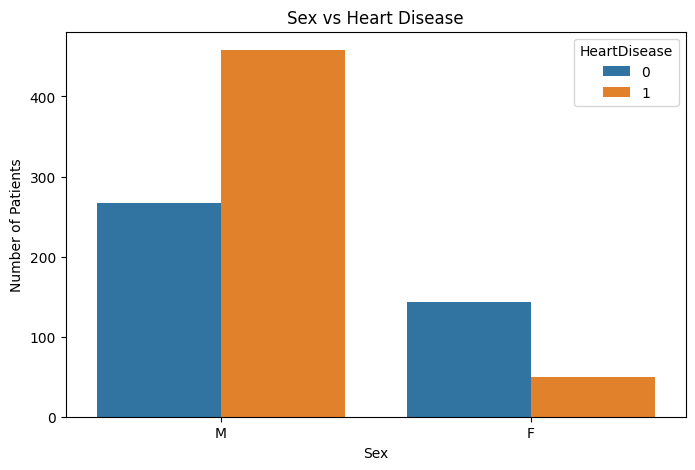

In [95]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Sex",
    hue="HeartDisease"
)

plt.title("Sex vs Heart Disease")
plt.xlabel("Sex")
plt.ylabel("Number of Patients")

plt.show()

**Target Distribution**

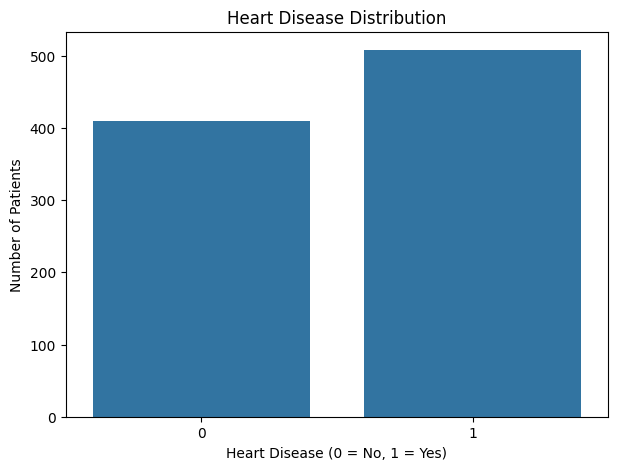

Target Distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64

Target Percentage:
HeartDisease
1    55.34
0    44.66
Name: proportion, dtype: float64


In [96]:
# Heart Disease Target Distribution
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df,
    x="HeartDisease"
)
plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.show()
print("Target Distribution:")
print(df["HeartDisease"].value_counts())
print("\nTarget Percentage:")
print((df["HeartDisease"].value_counts(normalize=True) * 100).round(2))

**Sex vs Heart Disease**

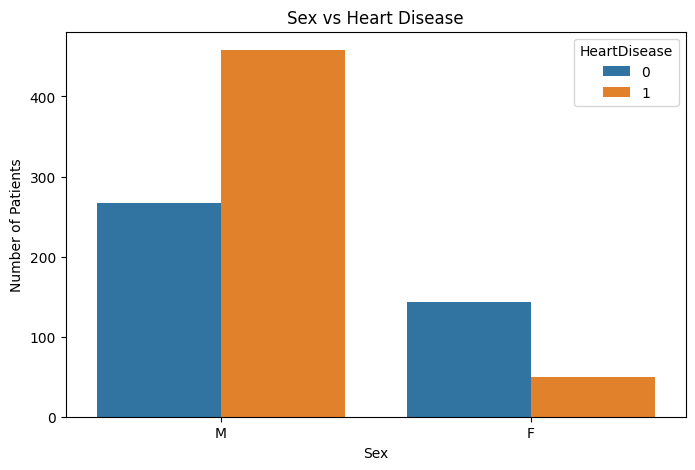

In [97]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="Sex",
    hue="HeartDisease"
)
plt.title("Sex vs Heart Disease")
plt.xlabel("Sex")
plt.ylabel("Number of Patients")
plt.show()

Resting ECG vs Heart Disease

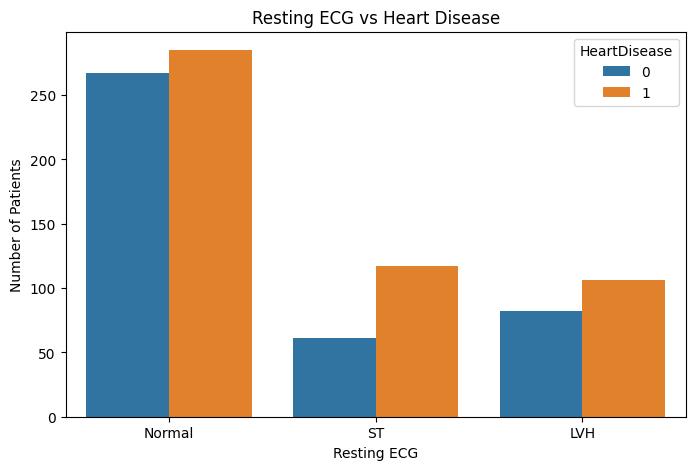

In [98]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="RestingECG",
    hue="HeartDisease"
)
plt.title("Resting ECG vs Heart Disease")
plt.xlabel("Resting ECG")
plt.ylabel("Number of Patients")
plt.show()

**Exercise Angina vs Heart Disease**

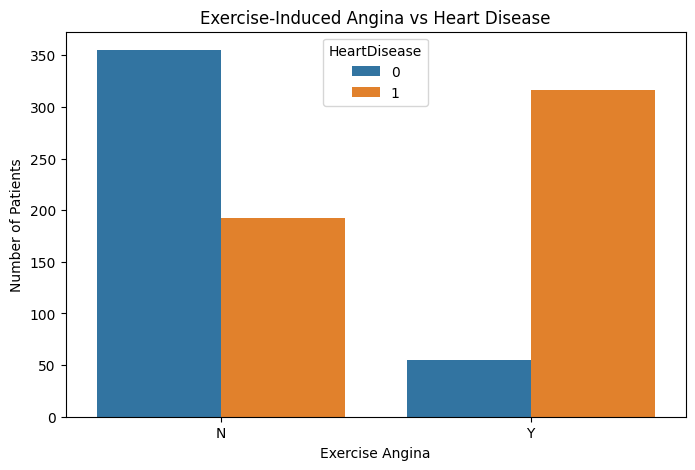

In [99]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="ExerciseAngina",
    hue="HeartDisease"
)
plt.title("Exercise-Induced Angina vs Heart Disease")
plt.xlabel("Exercise Angina")
plt.ylabel("Number of Patients")

plt.show()

**ST Slope vs Heart Disease**

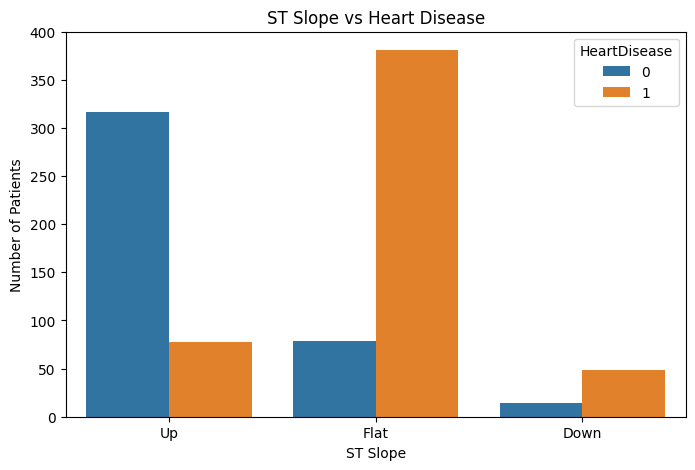

In [100]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="ST_Slope",
    hue="HeartDisease"
)
plt.title("ST Slope vs Heart Disease")
plt.xlabel("ST Slope")
plt.ylabel("Number of Patients")
plt.show()

**Correlation Heatmap**

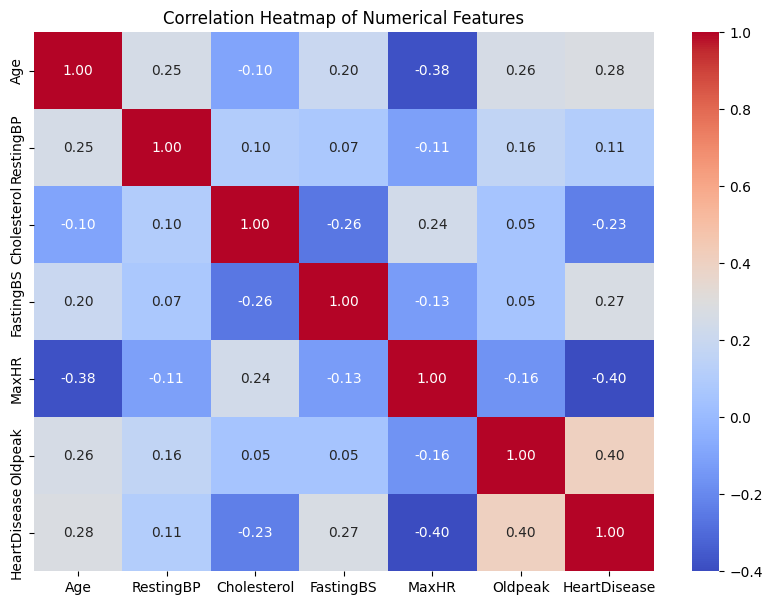

In [101]:
numeric_columns = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "Oldpeak",
    "HeartDisease"
]
correlation = df[numeric_columns].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

**Pairplot**

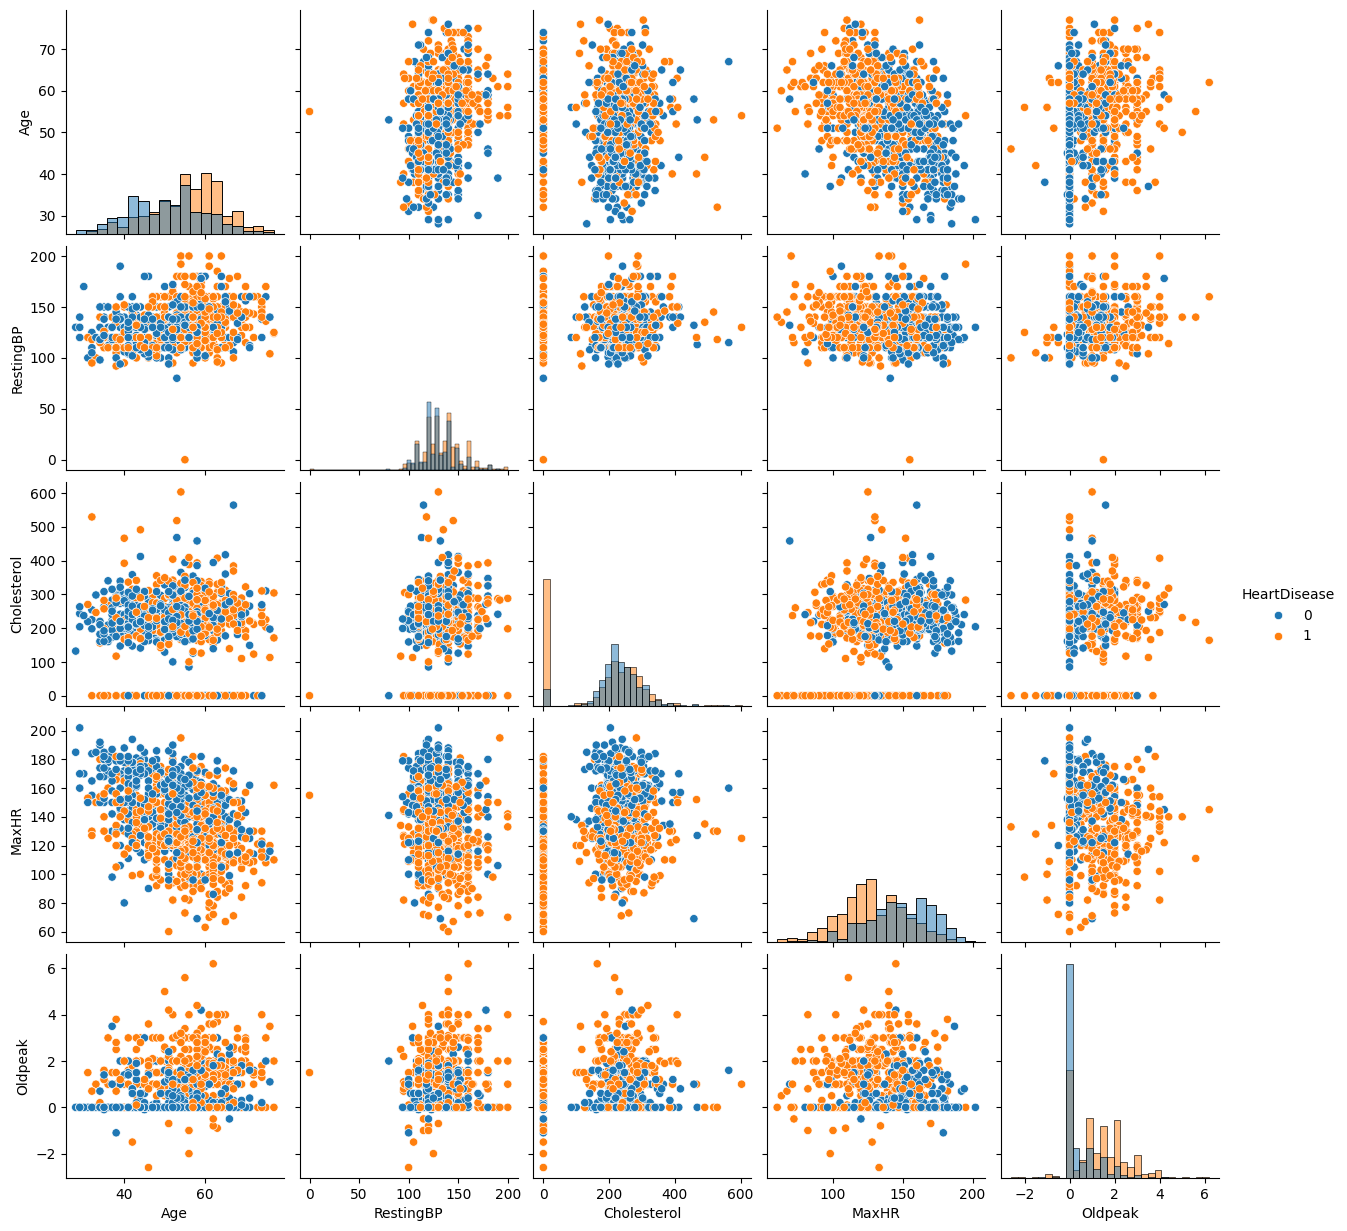

In [102]:
# Pairwise relationship between important numerical variables
sns.pairplot(
    df[
        [
            "Age",
            "RestingBP",
            "Cholesterol",
            "MaxHR",
            "Oldpeak",
            "HeartDisease"
        ]
    ],
    hue="HeartDisease",
    diag_kind="hist"
)
plt.show()

**Check Zero Values**

In [103]:
# Check zero values in numerical columns

zero_counts = (
    df[
        [
            "Age",
            "RestingBP",
            "Cholesterol",
            "FastingBS",
            "MaxHR",
            "Oldpeak"
        ]
    ] == 0
).sum()

print("Number of zero values:")
print(zero_counts)

Number of zero values:
Age              0
RestingBP        1
Cholesterol    172
FastingBS      704
MaxHR            0
Oldpeak        368
dtype: int64


**Prepare Dataset for Machine Learning**

In [104]:
# Create a separate copy for machine learning

df_model = df.copy()

# Replace physiologically invalid zero values with NaN
# These will later be imputed using the training data median.

df_model["RestingBP"] = df_model["RestingBP"].replace(0, np.nan)
df_model["Cholesterol"] = df_model["Cholesterol"].replace(0, np.nan)

print("Missing values after handling invalid zeros:")
print(df_model.isnull().sum())

Missing values after handling invalid zeros:
Age                 0
Sex                 0
ChestPainType       0
RestingBP           1
Cholesterol       172
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak             0
ST_Slope            0
HeartDisease        0
dtype: int64


**Separate Features and Target**

In [105]:
# Features
X = df_model.drop("HeartDisease", axis=1)

# Target
y = df_model["HeartDisease"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (918, 11)
Target shape: (918,)


**Define Numerical and Categorical Features**

In [106]:
# Numerical features
numerical_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "Oldpeak"
]

# Categorical features
categorical_features = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

Categorical Features:
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


**Train-Test Split**

In [107]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set shape: (734, 11)
Testing set shape: (184, 11)

Training target distribution:
HeartDisease
1    406
0    328
Name: count, dtype: int64

Testing target distribution:
HeartDisease
1    102
0     82
Name: count, dtype: int64


**Import Preprocessing Tools**

In [108]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

**Numerical Preprocessing Pipeline**

In [109]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

**Categorical Preprocessing Pipeline**

In [110]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

**Combine Preprocessing**

In [111]:
categorical_transformer = Pipeline(
    steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


**Import Machine Learning Models**

In [112]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

**Create All Six Model Pipelines**

In [113]:
models = {

    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "K-Nearest Neighbours": Pipeline([
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            random_state=42,
            max_depth=5
        ))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ))
    ]),

    "Support Vector Machine": Pipeline([
        ("preprocessor", preprocessor),
        ("model", SVC(
            probability=True,
            random_state=42
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(
            random_state=42
        ))
    ])
}

print("Six machine learning models created successfully.")

Six machine learning models created successfully.


**Train All Models**

In [114]:
for name, model in models.items():

    model.fit(X_train, y_train)

    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
K-Nearest Neighbours trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
Support Vector Machine trained successfully.
Gradient Boosting trained successfully.


**Import Evaluation Metrics**

In [115]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

**Evaluate All Models**

In [116]:
results = []

predictions = {}

probabilities = {}

for name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Probability of positive class
    y_prob = model.predict_proba(X_test)[:, 1]

    predictions[name] = y_pred
    probabilities[name] = y_prob

    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.885870,0.885714,0.911765,0.898551,0.932927
1,K-Nearest Neighbours,0.864130,0.881188,0.872549,0.876847,0.926889
2,Decision Tree,0.788043,0.811881,0.803922,0.807882,0.845827
3,Random Forest,0.891304,0.886792,0.921569,0.903846,0.930835
4,Support Vector Machine,0.875000,0.862385,0.921569,0.890995,0.942133
5,Gradient Boosting,0.869565,0.890000,0.872549,0.881188,0.914395


**Rounded Model Comparison**

In [117]:
# Display model performance with rounded values

results_rounded = results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

results_rounded[metric_columns] = (
    results_rounded[metric_columns].round(4)
)

results_rounded

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8859,0.8857,0.9118,0.8986,0.9329
1,K-Nearest Neighbours,0.8641,0.8812,0.8725,0.8768,0.9269
2,Decision Tree,0.7880,0.8119,0.8039,0.8079,0.8458
3,Random Forest,0.8913,0.8868,0.9216,0.9038,0.9308
4,Support Vector Machine,0.8750,0.8624,0.9216,0.8910,0.9421
5,Gradient Boosting,0.8696,0.8900,0.8725,0.8812,0.9144


**Sort Models by F1 Score**

In [118]:
model_ranking = (
    results_df
    .sort_values(
        by="F1 Score",
        ascending=False
    )
    .reset_index(drop=True)
)

model_ranking

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.891304,0.886792,0.921569,0.903846,0.930835
1,Logistic Regression,0.885870,0.885714,0.911765,0.898551,0.932927
2,Support Vector Machine,0.875000,0.862385,0.921569,0.890995,0.942133
3,Gradient Boosting,0.869565,0.890000,0.872549,0.881188,0.914395
4,K-Nearest Neighbours,0.864130,0.881188,0.872549,0.876847,0.926889
5,Decision Tree,0.788043,0.811881,0.803922,0.807882,0.845827


**Classification Reports**

In [119]:
for name in models:

    print("=" * 75)
    print(name)
    print("=" * 75)

    print(
        classification_report(
            y_test,
            predictions[name],
            target_names=[
                "No Heart Disease",
                "Heart Disease"
            ]
        )
    )

Logistic Regression
                  precision    recall  f1-score   support

No Heart Disease       0.89      0.85      0.87        82
   Heart Disease       0.89      0.91      0.90       102

        accuracy                           0.89       184
       macro avg       0.89      0.88      0.88       184
    weighted avg       0.89      0.89      0.89       184

K-Nearest Neighbours
                  precision    recall  f1-score   support

No Heart Disease       0.84      0.85      0.85        82
   Heart Disease       0.88      0.87      0.88       102

        accuracy                           0.86       184
       macro avg       0.86      0.86      0.86       184
    weighted avg       0.86      0.86      0.86       184

Decision Tree
                  precision    recall  f1-score   support

No Heart Disease       0.76      0.77      0.76        82
   Heart Disease       0.81      0.80      0.81       102

        accuracy                           0.79       184
       ma

**Confusion Matrices**

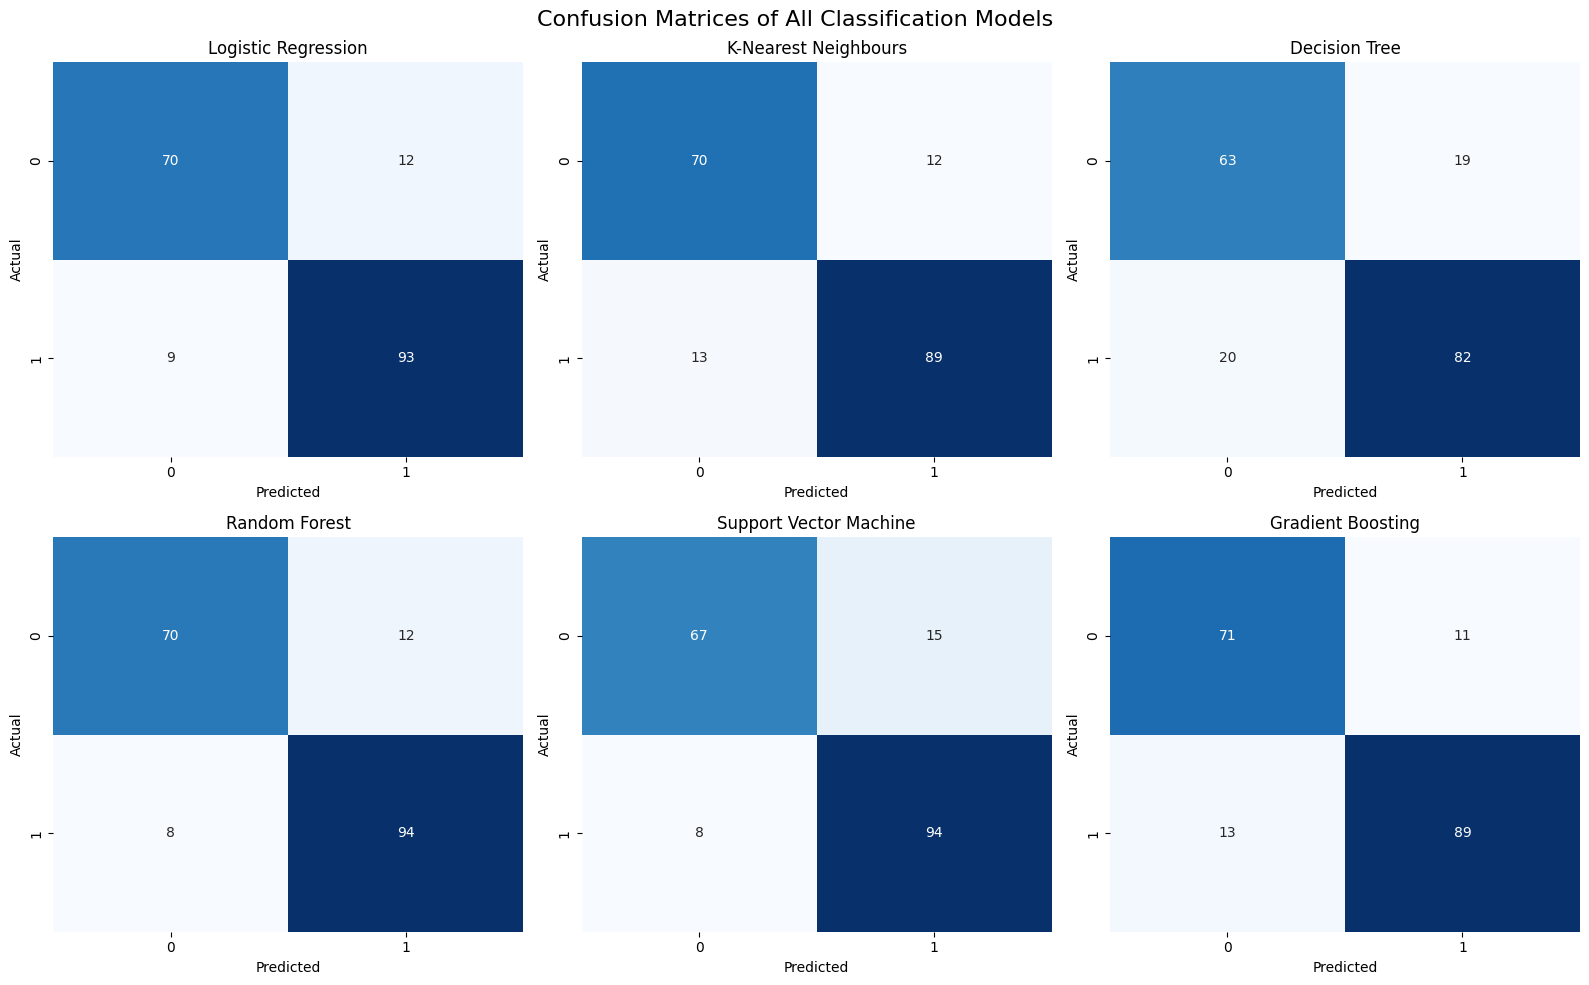

In [120]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 10)
)

axes = axes.ravel()

for ax, (name, y_pred) in zip(
    axes,
    predictions.items()
):

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle(
    "Confusion Matrices of All Classification Models",
    fontsize=16
)

plt.tight_layout()
plt.show()

**ROC Curves**

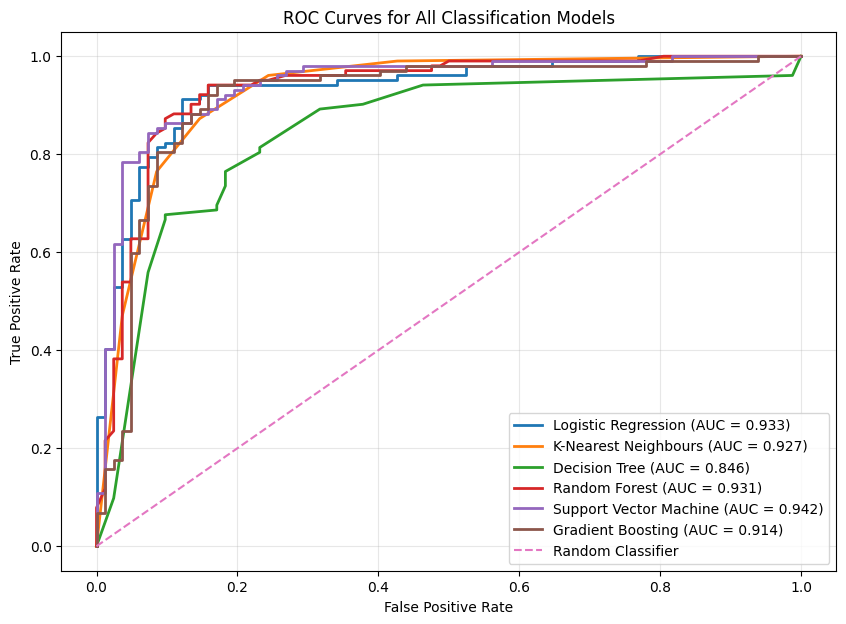

In [121]:
plt.figure(figsize=(10, 7))

for name, y_prob in probabilities.items():

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_prob
    )

    auc_score = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

# Random classifier reference line

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curves for All Classification Models"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

**Model Performance Comparison**

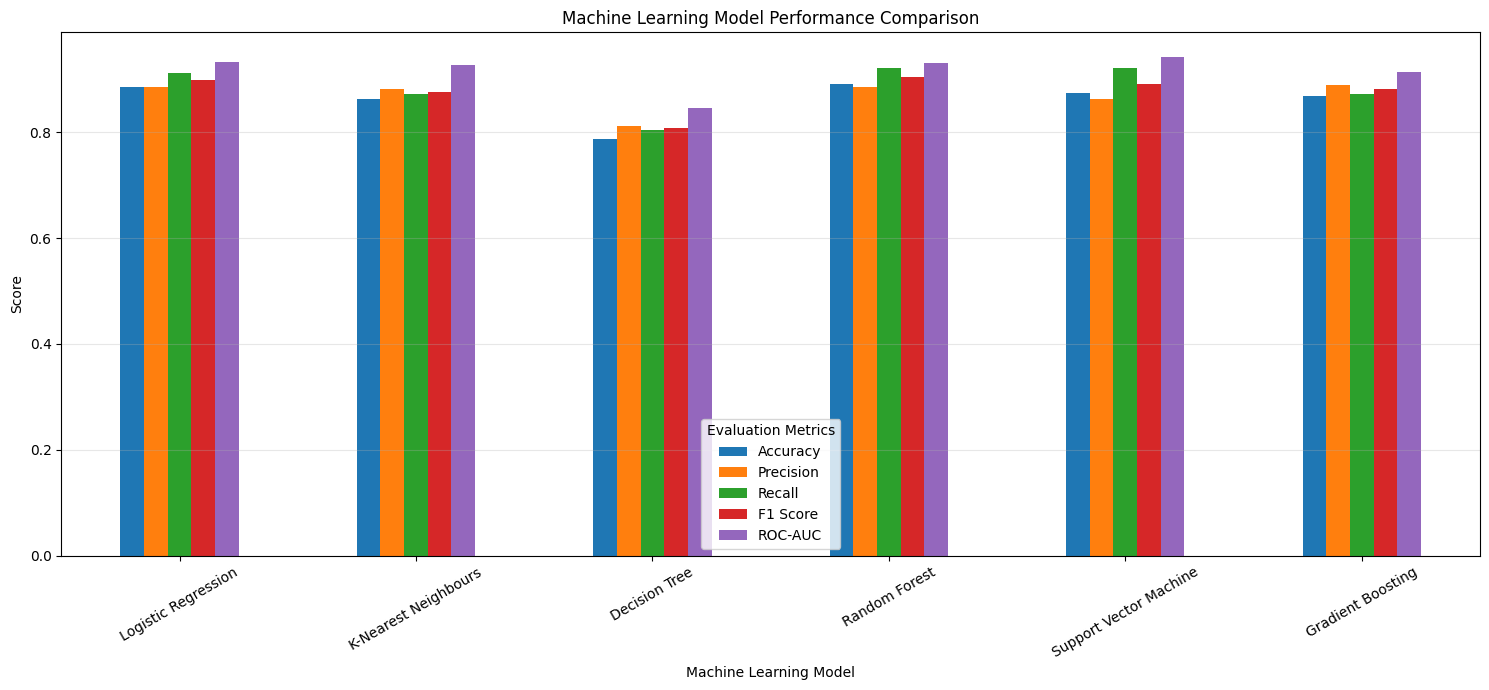

In [122]:
comparison = results_df.set_index("Model")

comparison.plot(
    kind="bar",
    figsize=(15, 7)
)

plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score")

plt.xticks(rotation=30)

plt.legend(
    title="Evaluation Metrics"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

**Accuracy Comparison**

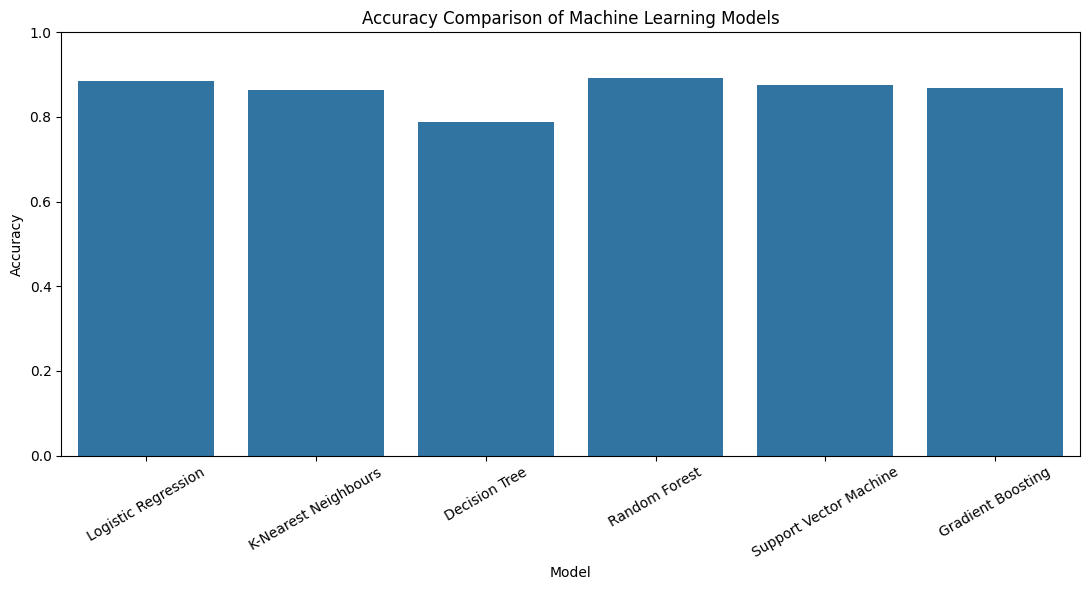

In [123]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=30)

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

**F1 Score Comparison**

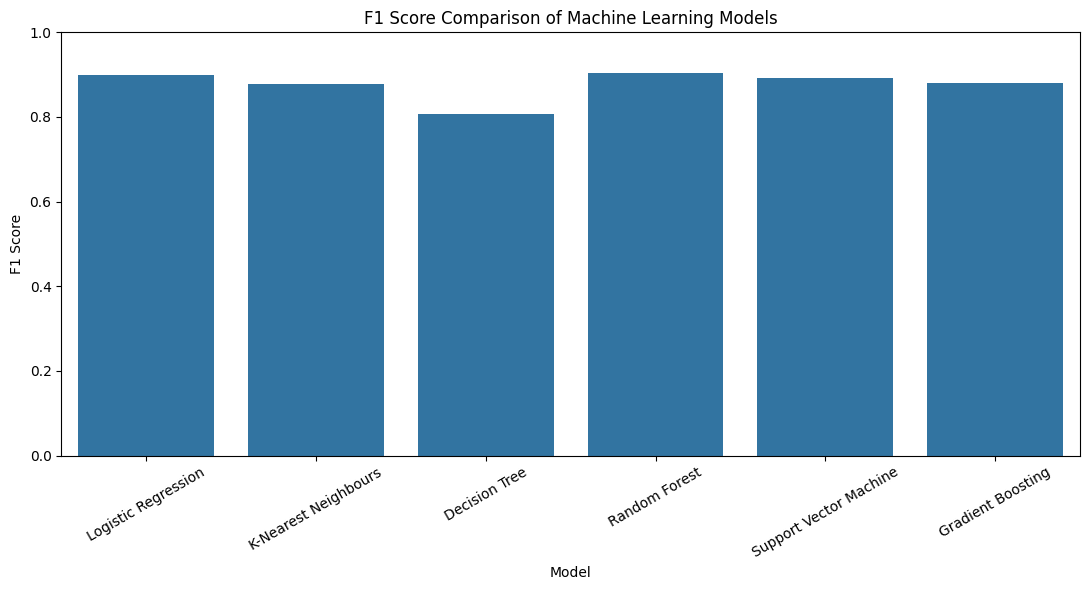

In [124]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1 Score"
)

plt.title("F1 Score Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("F1 Score")

plt.xticks(rotation=30)

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

**Random Forest Feature Importance**

In [125]:
# Select the trained Random Forest pipeline

rf_pipeline = models["Random Forest"]

# Extract fitted preprocessing component

fitted_preprocessor = (
    rf_pipeline
    .named_steps["preprocessor"]
)

# Get transformed feature names

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

# Get feature importance from Random Forest

importances = (
    rf_pipeline
    .named_steps["model"]
    .feature_importances_
)

# Create DataFrame

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort by importance

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance_df.head(20)

,Feature,Importance
0,cat__ST_Slope_Up,0.153272
1,cat__ST_Slope_Flat,0.100136
2,num__MaxHR,0.097870
3,num__Oldpeak,0.093628
4,cat__ChestPainType_ASY,0.093205
5,num__Cholesterol,0.075407
6,num__Age,0.073681
7,num__RestingBP,0.066773
8,cat__ExerciseAngina_N,0.052617
9,cat__ExerciseAngina_Y,0.050690


**Plot Top 15 Features**

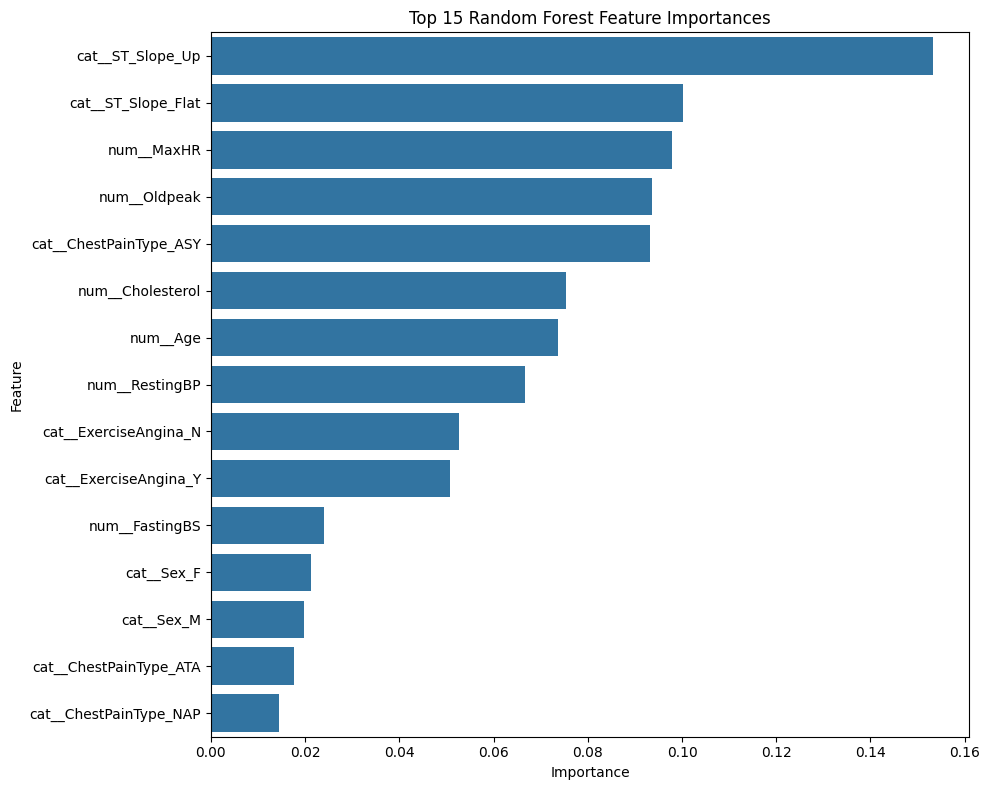

In [126]:
plt.figure(figsize=(10, 8))

top_features = feature_importance_df.head(15)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Random Forest Feature Importances"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

**Clean Feature Names**

In [127]:
clean_feature_importance = feature_importance_df.copy()

clean_feature_importance["Feature"] = (
    clean_feature_importance["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

clean_feature_importance.head(20)

,Feature,Importance
0,ST_Slope_Up,0.153272
1,ST_Slope_Flat,0.100136
2,MaxHR,0.097870
3,Oldpeak,0.093628
4,ChestPainType_ASY,0.093205
5,Cholesterol,0.075407
6,Age,0.073681
7,RestingBP,0.066773
8,ExerciseAngina_N,0.052617
9,ExerciseAngina_Y,0.050690


**Plot Clean Feature Importance**

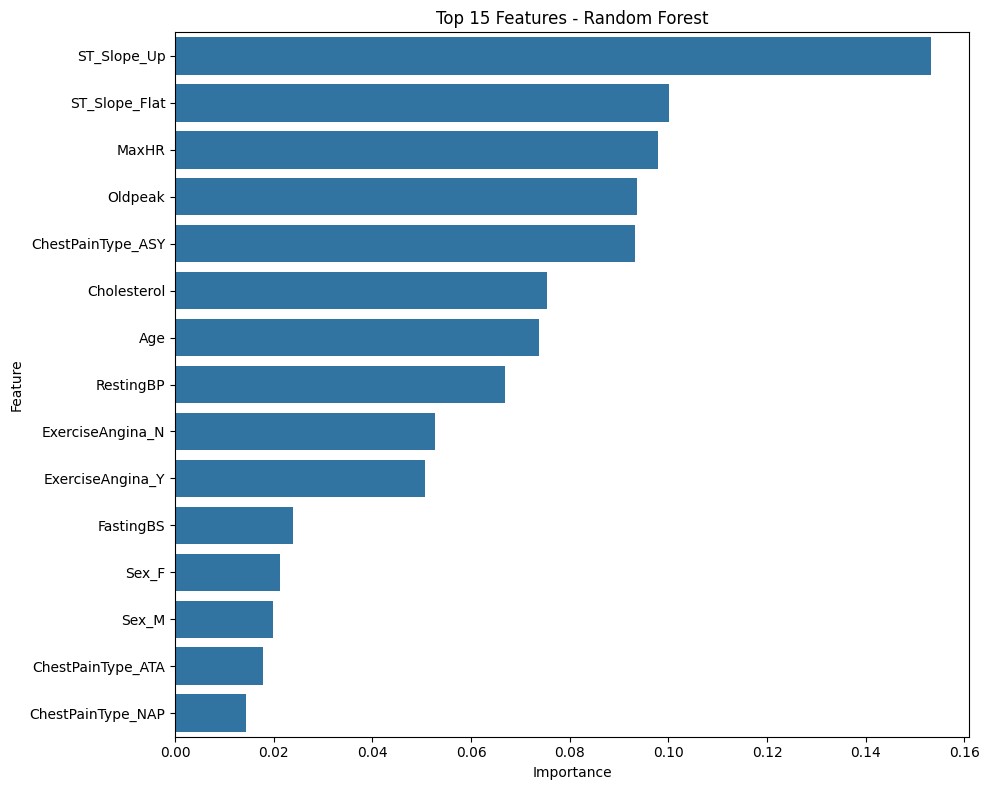

In [128]:
plt.figure(figsize=(10, 8))

top_features = clean_feature_importance.head(15)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Features - Random Forest"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

**Identify the Best Model**

In [129]:
# Select the model with the highest F1 Score

best_model_name = (
    results_df
    .sort_values(
        by="F1 Score",
        ascending=False
    )
    .iloc[0]["Model"]
)

best_model = models[best_model_name]

print("Best Performing Model:")
print(best_model_name)

print("\nPerformance of Best Model:")

display(
    results_df[
        results_df["Model"] == best_model_name
    ].round(4)
)

Best Performing Model:
Random Forest

Performance of Best Model:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Random Forest,0.8913,0.8868,0.9216,0.9038,0.9308


**Best Model Classification Report**

In [130]:
print(
    classification_report(
        y_test,
        predictions[best_model_name],
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ]
    )
)

                  precision    recall  f1-score   support

No Heart Disease       0.90      0.85      0.88        82
   Heart Disease       0.89      0.92      0.90       102

        accuracy                           0.89       184
       macro avg       0.89      0.89      0.89       184
    weighted avg       0.89      0.89      0.89       184



**Best Model Confusion Matrix**

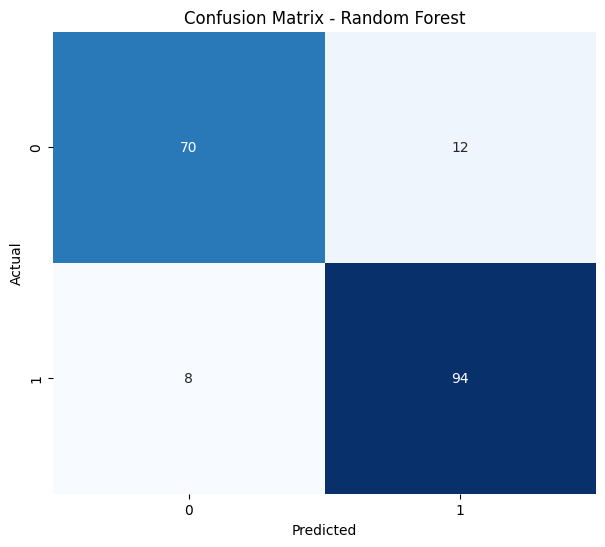

In [131]:
best_cm = confusion_matrix(
    y_test,
    predictions[best_model_name]
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    best_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**New Patient Data**

In [132]:
# Example patient for demonstrating model prediction

new_patient = pd.DataFrame({
    "Age": [55],
    "Sex": ["M"],
    "ChestPainType": ["ATA"],
    "RestingBP": [140],
    "Cholesterol": [250],
    "FastingBS": [0],
    "RestingECG": ["Normal"],
    "MaxHR": [150],
    "ExerciseAngina": ["N"],
    "Oldpeak": [1.0],
    "ST_Slope": ["Flat"]
})

new_patient

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,55,M,ATA,140,250,0,Normal,150,N,1.0,Flat


**Predict New Patient**

In [133]:
# Make prediction using the best-performing model

prediction = best_model.predict(
    new_patient
)[0]

probability = best_model.predict_proba(
    new_patient
)[0][1]

print("Predicted Class:", prediction)

print(
    f"Probability of Heart Disease: "
    f"{probability:.2%}"
)

Predicted Class: 1
Probability of Heart Disease: 63.67%


**Display Human-Readable Result**

In [134]:
if prediction == 1:

    print(
        "Model Prediction: Heart Disease = YES"
    )

else:

    print(
        "Model Prediction: Heart Disease = NO"
    )

Model Prediction: Heart Disease = YES


**Final Model Summary**

In [135]:
# Final model summary

best_result = (
    results_df[
        results_df["Model"] == best_model_name
    ]
    .iloc[0]
)

print("=" * 60)
print("FINAL MODEL SUMMARY")
print("=" * 60)

print(f"Best Model : {best_model_name}")
print(f"Accuracy   : {best_result['Accuracy']:.4f}")
print(f"Precision  : {best_result['Precision']:.4f}")
print(f"Recall     : {best_result['Recall']:.4f}")
print(f"F1 Score   : {best_result['F1 Score']:.4f}")
print(f"ROC-AUC    : {best_result['ROC-AUC']:.4f}")

FINAL MODEL SUMMARY
Best Model : Random Forest
Accuracy   : 0.8913
Precision  : 0.8868
Recall     : 0.9216
F1 Score   : 0.9038
ROC-AUC    : 0.9308


# Conclusion

This project developed an end-to-end supervised machine learning workflow for
heart disease classification using clinical and physiological features.

The dataset was explored through descriptive statistics and multiple
visualizations. Data quality was examined, duplicate records were checked,
and physiologically invalid zero values in selected numerical measurements
were handled during preprocessing.

Five categorical features were encoded using One-Hot Encoding, while
numerical features were imputed using the median and standardized using
StandardScaler.

Six supervised classification algorithms were trained and compared:

1. Logistic Regression
2. K-Nearest Neighbours
3. Decision Tree
4. Random Forest
5. Support Vector Machine
6. Gradient Boosting

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Confusion Matrix
- ROC Curve

For this project, F1-Score was used as the primary criterion for selecting
the best-performing model because it provides a balance between precision and
recall.

Random Forest feature importance was also analyzed to understand which
processed features contributed most strongly to the model's predictions.

The final model was then used to demonstrate prediction on a sample patient
record.

Overall, the project demonstrates a complete machine learning pipeline from
data preprocessing and exploratory analysis to model training, evaluation,
comparison, interpretation, and prediction.

**Important:** The predictions generated by this project are intended only
for educational and machine learning demonstration purposes. They should not
be interpreted as a medical diagnosis or used as a substitute for
professional medical evaluation.